Part 1: Data Preparation

 1. Loading the Iris dataset and performing exploratory data analysis

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Iris dataset
iris = load_iris()
x = iris.data
y = iris.target

# Creating a Dataframe for easier EDA
df = pd.DataFrame(x, columns=iris.feature_names)
df['species'] = iris.target_names[y]

print(f"Features (x) shape: {x.shape}")
print(f"Target (y) shape: {y.shape}")

display(df.head())

print("\nDataset Information:")
df.info()
df['species'].unique()

Features (x) shape: (150, 4)
Target (y) shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


array(['setosa', 'versicolor', 'virginica'], dtype=object)

#### 2. Visualize feature distributions using histograms and pair plots

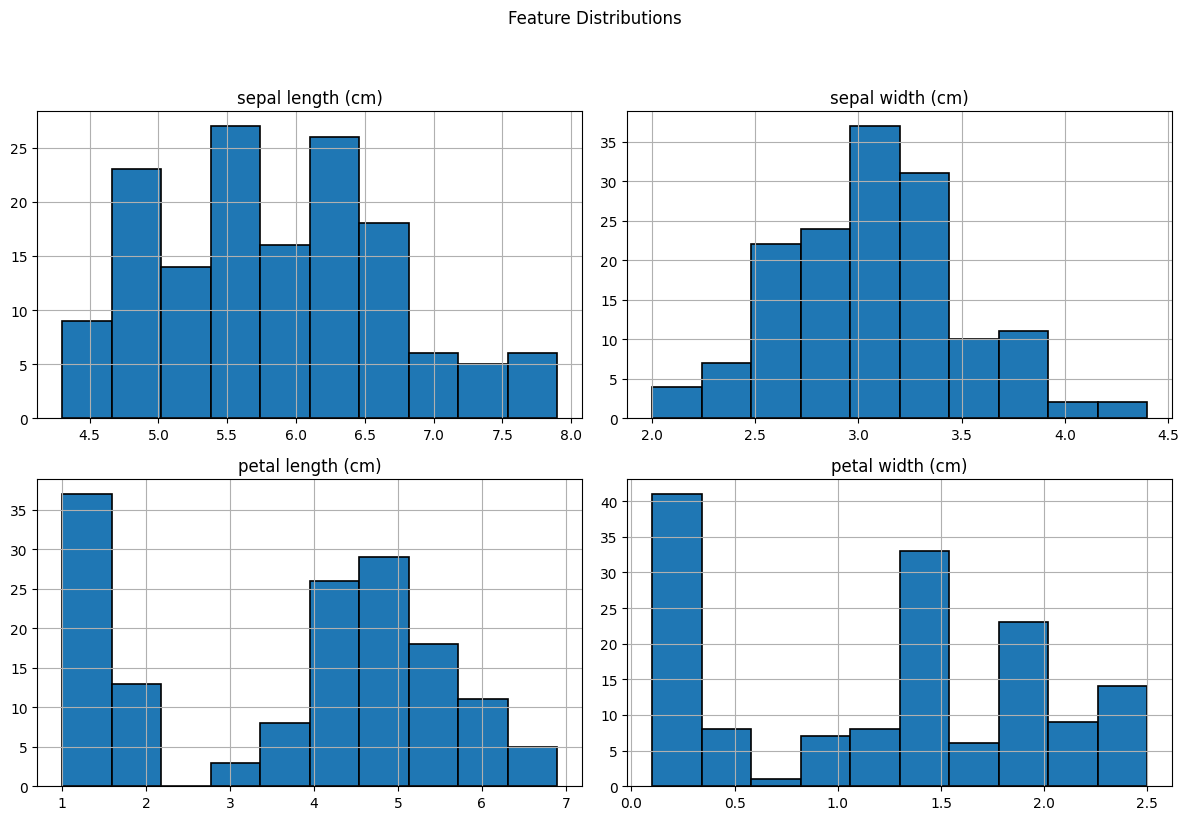

In [4]:
# Histograms for each feature
df.hist(edgecolor='black', linewidth=1.2, figsize=(12, 8))
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

<Figure size 1000x800 with 0 Axes>

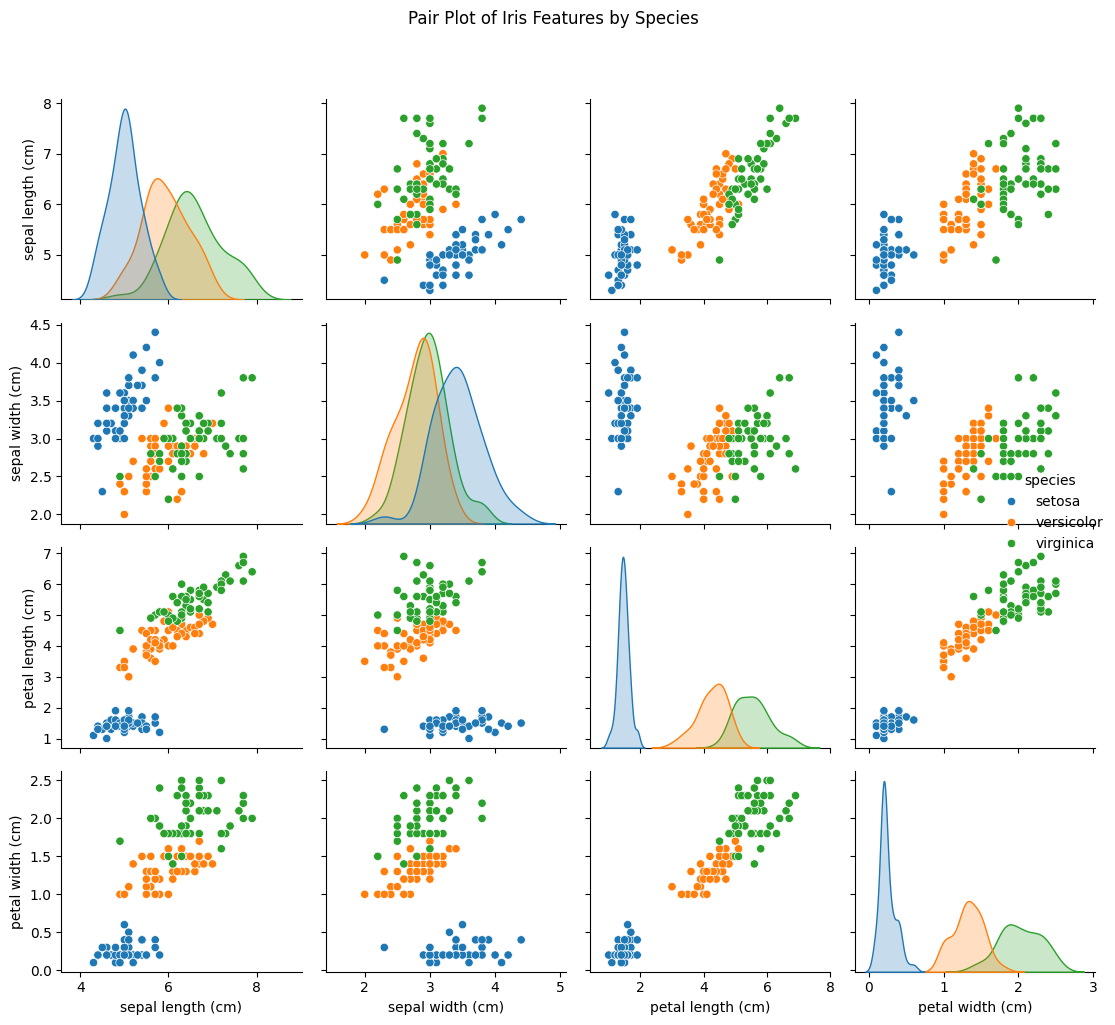

In [5]:
# Pair plot to visualize relationships between features and species
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

3. Split the dataset into training (70%), validation (15%), and test (15%) sets

In [6]:
from sklearn.model_selection import train_test_split

# Split into training (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30, random_state=42, stratify=y)

# Split temp (30%) into validation (15%) and test (15%)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

x_train shape: (105, 4), y_train shape: (105,)
x_val shape: (22, 4), y_val shape: (22,)
x_test shape: (23, 4), y_test shape: (23,)


#### 4. Normalize/standardize features using z-score normalization

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fitting on training data and transforming all splits
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

print("First 5 rows of x_train_scaled:")
display(x_train_scaled[:5])
print("First 5 rows of x_val_scaled:")
display(x_val_scaled[:5])
print("First 5 rows of x_test_scaled:")
display(x_test_scaled[:5])

Features normalized using StandardScaler.
First 5 rows of x_train_scaled:


array([[-0.90045861, -1.22024754, -0.4419858 , -0.13661044],
       [ 0.38036614, -1.87955796,  0.40282929,  0.38029394],
       [-0.90045861,  1.63676428, -1.2868009 , -1.17041921],
       [ 1.07899781,  0.31814344,  1.19132338,  1.41410271],
       [-0.20182693, -0.56093712,  0.17754527,  0.12184175]])

First 5 rows of x_val_scaled:


array([[ 0.9625592 , -0.12139684,  0.68443432,  0.63874613],
       [ 0.61324336, -0.78070726,  0.85339734,  0.89719832],
       [-0.31826554, -1.22024754,  0.06490325, -0.13661044],
       [ 0.49680475, -0.56093712,  0.74075533,  0.38029394],
       [ 1.19543642,  0.0983733 ,  0.74075533,  1.41410271]])

First 5 rows of x_test_scaled:


array([[-0.20182693,  1.63676428, -1.17415888, -1.17041921],
       [-1.7155289 , -0.12139684, -1.39944291, -1.29964531],
       [ 0.26392752, -1.0004774 ,  1.02236036,  0.25106784],
       [-1.13333583, -1.44001768, -0.27302278, -0.26583654],
       [ 0.26392752, -0.12139684,  0.62811332,  0.76797223]])

#### 5. Convert labels to one-hot encoded vectors

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

# Reshaping y to be 2D for OneHotEncoder
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_val_onehot = encoder.transform(y_val.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print("Labels converted to one-hot encoded vectors.")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"y_val_onehot shape: {y_val_onehot.shape}")
print(f"y_test_onehot shape: {y_test_onehot.shape}")

print("\nFirst 5 rows of y_train_onehot:")
display(y_train_onehot[:5])

Labels converted to one-hot encoded vectors.
y_train_onehot shape: (105, 3)
y_val_onehot shape: (22, 3)
y_test_onehot shape: (23, 3)

First 5 rows of y_train_onehot:


array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])